In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sparse, sys, warnings, yaml, vcf, pickle, shutil
import scipy.optimize

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from analysis_utils import *
import seaborn as sns
import scipy.stats as st
plt.rcParams['figure.dpi'] = 150

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression

from Bio import SeqIO
warnings.filterwarnings("ignore")

data_path = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
freschi_2020 = pd.read_csv("/home/sak0914/who-analysis/data/freschi2020_SNP_scheme.tsv", sep="\t")

cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
solo_results = pd.read_excel("/home/sak0914/who-analysis/results/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name="Sheet1")

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETH",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

# CRyPTIC Essential Agreements (for comparing to Lachapelle et al., 2021)

In [4]:
def compute_cryptic_EA(drug, path, thresh):

    test_pred = pd.read_csv(os.path.join(results_path, path, "test_predictions.csv"))
    df_phenos = pd.read_csv(os.path.join(data_path, drug, "data_for_model.csv"))
    
    test_pred_cryptic = test_pred.loc[test_pred["Isolate"].isin(df_phenos.query("DB_OF_ORIGIN=='CRyPTIC'").ROLLINGDB_ID.values)]

    # y_test column is log2-transformed
    test_pred_cryptic_R = test_pred_cryptic.query("y_test > @thresh")
    test_pred_cryptic_S = test_pred_cryptic.query("y_test <= @thresh")
    print(len(test_pred), len(test_pred_cryptic), len(test_pred_cryptic_R), len(test_pred_cryptic_S))
    
    print(f"\nFull: {np.round(test_pred.within_doubling.mean(), 3)}")
    print(f"CRyPTIC: {np.round(test_pred_cryptic.within_doubling.mean(), 3)}")
    print(f"CRyPTIC-R: {np.round(test_pred_cryptic_R.within_doubling.mean(), 3)}")
    print(f"CRyPTIC-S: {np.round(test_pred_cryptic_S.within_doubling.mean(), 3)}")

In [2]:
# drug = "RIF"
# path = "RIF_rpoBC"
# compute_cryptic_EA(drug, path, np.log2(0.5))

In [41]:
drug = "INH"
path = "INH_4Loci"
compute_cryptic_EA(drug, path, np.log2(0.2))

1941 1629 811 818

Full: 0.907
CRyPTIC: 0.919
CRyPTIC-R: 0.848
CRyPTIC-S: 0.989


In [42]:
drug = "EMB"
path = "EMB_2Loci"
compute_cryptic_EA(drug, path, np.log2(5))

1651 1349 270 1079

Full: 0.86
CRyPTIC: 0.918
CRyPTIC-R: 0.915
CRyPTIC-S: 0.918


In [49]:
drug = "MXF"
path = "MXF_gyrBA_lineage"
compute_cryptic_EA(drug, path, np.log2(0.5))

1454 1216 186 1030

Full: 0.9
CRyPTIC: 0.921
CRyPTIC-R: 0.876
CRyPTIC-S: 0.929


# Replicates Evaluation

Plot validation loss for the 10 bootstrapped replicates and the actual model on top. 

In [2]:
# plot_histories(os.path.join(results_path, "INH_4Loci"), rep_CV=False, binary=False, patience_epochs=25)

In [3]:
# plot_histories(os.path.join(results_path, "EMB_2Loci"), rep_CV=False, binary=False, patience_epochs=25)

In [4]:
# plot_histories(os.path.join(results_path, "EMB_2Loci_lineage"), rep_CV=False, binary=False, patience_epochs=25)

# Analyze quantitative CNN

In [2]:
def plot_model_results(df, variable_lst, tick_labels, sharey, meanLine_width=0.3, lower_bounds=None, upper_bounds=None, savefName=None):
    
    if len(variable_lst) <= 3:
        col_wrap = None
    else:
        col_wrap =2
    
    plot_df = df.query("CV > 0").melt(id_vars=["Model", "Lineage"], value_vars=variable_lst)
    plot_df["Model"] = plot_df["Model"].replace("LinReg", "Regression")
    plot_df["Model"] = plot_df["Model"].replace("LogReg", "Regression")
    
    palette = sns.color_palette("Set2").as_hex()
    color_dict = dict(zip(plot_df.Model.unique(), palette[:len(plot_df.Model.unique())]))
        
    g = sns.catplot(data=plot_df, 
                    x="Lineage", 
                    y="value", 
                    hue="Model", 
                    col="variable", 
                    col_order=variable_lst,
                    col_wrap=col_wrap,
                    hue_order=["Regression", "CNN"], 
                    kind="strip", 
                    dodge=True,
                    aspect=0.9, 
                    height=4, 
                    linewidth=0.5,
                    palette=color_dict,
                    sharex=False,
                    sharey=sharey,
                    legend_out=True
                   )

    for i, (col_name, ax) in enumerate(g.axes_dict.items()):

        sns.pointplot(data=plot_df.query("variable == @col_name"),
                      x="Lineage", 
                      y="value", 
                      hue="Model", 
                      hue_order=["Regression", "CNN"], 
                      palette=color_dict, 
                      dodge=0.4, 
                      join=False, 
                      ci=0, 
                      errwidth=2, # thickness
                      capsize=meanLine_width,  # height
                      scale=0, 
                      ax=ax
                     )

        if not sharey:
            if type(lower_bounds) == np.ndarray or type(lower_bounds) == list:
                ax.set_ylim(lower_bounds[i], upper_bounds[i])

        # don't add another legend from the pointplot function
        ax.get_legend().remove()


    # put a box around the legend
    sns.move_legend(g, title="", loc="center right", frameon=True, fontsize="small")

    g.set(xlabel=None, ylabel=None)
    g.set_titles(template='{col_name}\n')
    g.set_xticklabels(tick_labels)

    if sharey:
        if lower_bound is not None and upper_bound is not None:
            g.set(ylim=(lower_bound, upper_bound))
    
    sns.despine()
    # plt.tight_layout()
    
    if savefName is None:
        plt.show()
    else:
        plt.savefig(savefName, dpi=300)

In [3]:
def plot_ridge_results(path, saveName=None):
    
    pred_df = pd.read_csv(os.path.join(path, "ridge/test_predictions.csv"))
                          
    fig, ax = plt.subplots(figsize=(5, 4))
    
    values = np.vstack([pred_df["y_pred"], pred_df["y_test"]])
    kernel = st.gaussian_kde(values)(values)

    sns.scatterplot(
        data=pred_df,
        x="y_pred",
        y="y_test",
        c=kernel,
        cmap="Blues",
        linewidth=0.25,
        edgecolor="lightgray",
        ax=ax
    )
    
    max_val = np.max([pred_df.y_pred, pred_df.y_test]) * 1.1
    min_val = np.min([pred_df.y_pred, pred_df.y_test]) * 1.1

    ax.set_xlabel("\nPredicted MIC (µg/mL)", fontsize=9)
    ax.set_ylabel("Actual MIC (µg/mL)", fontsize=9)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    
    # ax.set_xticks(ticks=ax.get_xticks(), labels=np.round(np.exp2(ax.get_xticks()), 2))
    # ax.set_yticks(ticks=ax.get_yticks(), labels=np.round(np.exp2(ax.get_yticks()), 2))
#     max_log2 = 10
#     ax.set_xticks(ticks=np.concatenate([np.array([0]), np.linspace(0, max_log2, max_log2+1)]), labels=np.concatenate([np.array([0]), np.exp2(np.linspace(0, max_log2, max_log2+1))]))
#     ax.set_yticks(ticks=np.concatenate([np.array([0]), np.linspace(0, max_log2, max_log2+1)]), labels=np.concatenate([np.array([0]), np.exp2(np.linspace(0, max_log2, max_log2+1))]))
    
    # smallest_power = -6
    # largest_power = 3
    smallest_power = np.floor(np.min([pred_df.y_pred, pred_df.y_test]))
    largest_power = np.ceil(np.max([pred_df.y_pred, pred_df.y_test]))
    smallest_power = -8
    
    tick_labels = []

    for num in np.exp2(np.linspace(smallest_power, largest_power, 11)):
        if num < 1:
            tick_labels.append(str(np.round(num, 2)))
        else:
            tick_labels.append(str(int(num)))
        
    ax.set_xticks(ticks=np.linspace(smallest_power, largest_power, 11), labels=tick_labels)
    ax.set_yticks(ticks=np.linspace(smallest_power, largest_power, 11), labels=tick_labels)
    
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    
    sns.despine()
    plt.tight_layout()
    
    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName, dpi=300)
        
        
        
def test_for_significance(x1, x2, var, alt="two-sided"):
    
    assert sum(~pd.isnull(x1.query("CV>0")[var].values)) == sum(~pd.isnull(x2.query("CV>0")[var].values))
    return st.mannwhitneyu(x1.query("CV>0")[var], x2.query("CV>0")[var], alternative=alt)[1]
        
        
def compare_two_models(model_1, model_2, test_variables=["Binned_MAE", "Binned_MSE", "Spearman", "Within_1Bin", "Within_doubling", "Sensitivity", "Specificity", "Balanced_Acc"]):
    '''
    Directionality is important. Put the one hypothesized to be better FIRST
    '''
    # lineage does not significantly improve RIF prediction
    for var in test_variables:

        pval = test_for_significance(model_1, model_2, var, alt="two-sided")

        # if the two-sided test is significant, then try one-sided, based on the variable
        if pval < 0.05:

            if "MAE" in var or "MSE" in var or "Without" in var:
                alt = "less"
            else:
                alt = "greater"
        
            pval = test_for_significance(model_1, model_2, var, alt=alt)
            
            if pval < 0.05:
                print(f"{var} better, pval = {pval}")
            else:
                print(f"{var} worse, pval = {1-pval}")
        else:
            print(f"{var}, ns = {pval}")

In [4]:
def get_single_model_results(drug, path, include_lineage=False, patience=25, cv=True, plot=True):
    '''
    Gets results for lineage and regression, using kwargs
    '''

    drug_abbr = drug_abbr_dict[drug]
    
    df_CNN = quant_model_analysis(os.path.join(results_path, path), drug_abbr, lineage=0, patience=patience, cv=cv, plot=plot, saveName=f"{drug}/CNN_predictions.png")
    
    df_Reg = pd.read_csv(os.path.join(results_path, path, "ridge/ridge_results.csv"))

    df_combined = pd.concat([df_CNN, df_Reg], axis=0)
    
    if include_lineage:
        df_CNN_lineage = quant_model_analysis(os.path.join(results_path, f"{path}_lineage"), drug_abbr, lineage=1, patience=patience, cv=cv, plot=plot, saveName=f"{drug}/CNN_predictions.png")

        df_Reg_lineage = pd.read_csv(os.path.join(results_path, f"{path}_lineage/ridge/ridge_results.csv"))

        df_combined = pd.concat([df_combined, df_CNN_lineage, df_Reg_lineage], axis=0)

    df_combined["Without_1Bin"] = 1 - df_combined["Within_1Bin"]
    df_combined["Without_doubling"] = 1 - df_combined["Within_doubling"]
    return df_combined.reset_index(drop=True)

# All Drugs

In [5]:
# all_drugs_results = []

# for drug, model_path in list(zip(["Rifampicin", "Ethambutol", "Pyrazinamide", "Moxifloxacin", "Levofloxacin"],
#                                  ["RIF_rpoBC", "EMB_2Loci", "PZA_4Loci", "MXF_gyrBA", "LEV_gyrBA"]
#                                 )): # "Isoniazid"]:

#     df = get_single_model_results(drug, model_path, include_lineage=True, patience=0, cv=True, plot=False)
#     all_drugs_results.append(df)

# all_drugs_results = pd.concat(all_drugs_results)

In [6]:
# _ = get_single_model_results("Levofloxacin", "LEV_gyrBA", include_lineage=True, patience=50, cv=False, plot=True)

In [11]:
df_MXF = get_single_model_results("Moxifloxacin", "MXF_gyrBA", include_lineage=True, patience=50, cv=True, plot=False)
df_LEV = get_single_model_results("Levofloxacin", "LEV_gyrBA", include_lineage=True, patience=50, cv=True, plot=False)
df_PZA = get_single_model_results("Pyrazinamide", "PZA_4Loci", include_lineage=True, patience=75, cv=True, plot=False)

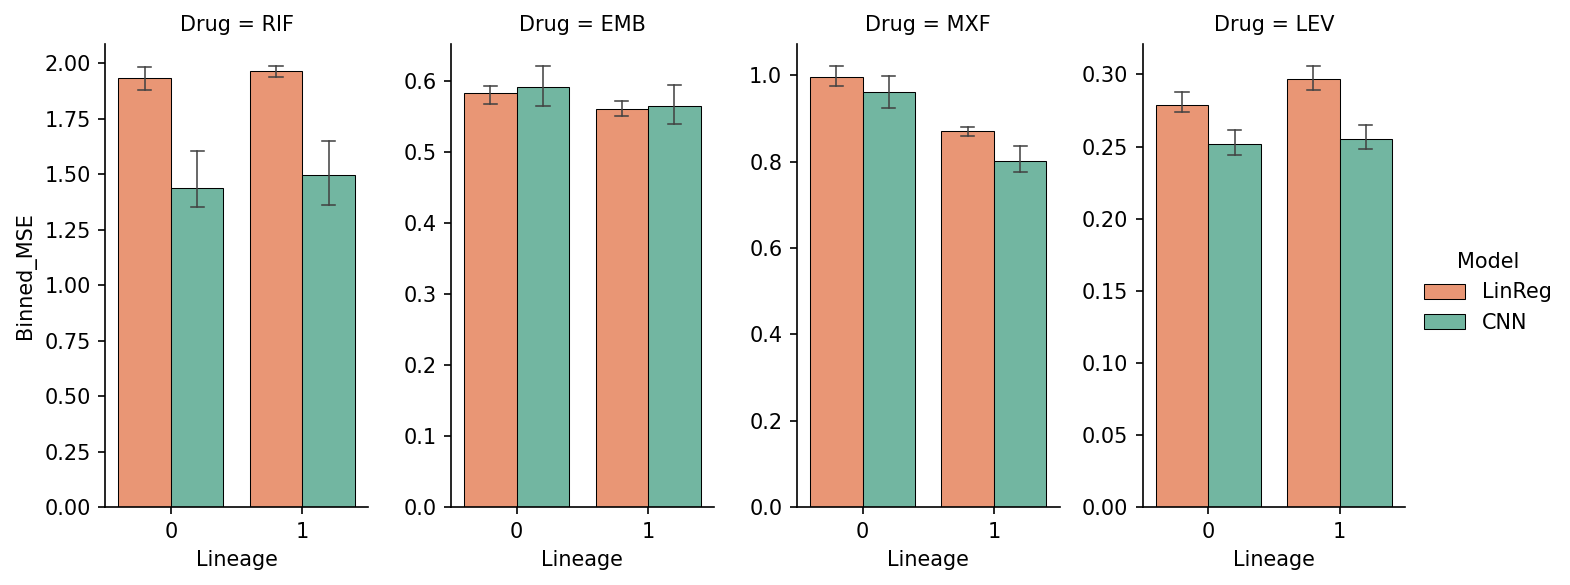

In [37]:
plot_var = "Binned_MSE"

g = sns.catplot(data=all_drugs_results.query("Drug != 'PZA'"), 
                x="Lineage", 
                y=plot_var, 
                hue="Model",
                hue_order=["LinReg", "CNN"],
                col="Drug",
                #col_wrap=3,
                sharey=False,
                kind="bar", 
                height=4, 
                aspect=.6,
                errorbar=("pi", 95),
                errwidth=0.75,
                capsize=0.1,
                edgecolor="black",
                linewidth=0.5,
                palette=dict(zip(["CNN", "LinReg"], sns.color_palette("Set2").as_hex())),
                #dodge=True
            )
# g.set_axis_labels("", "Survival Rate")
# g.set_xticklabels(["Men", "Women", "Children"])
# g.set_titles("{col_name} {col_var}")
# g.set(ylim=(0, 0.25))
g.despine()

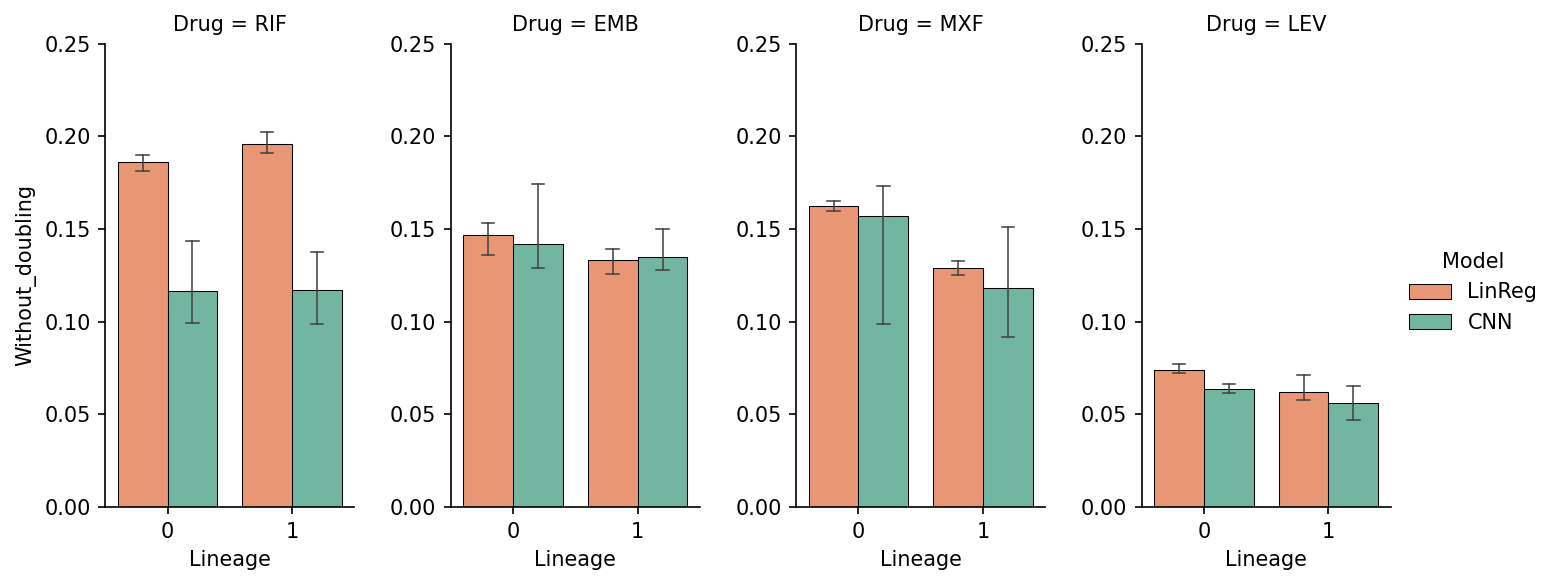

In [32]:
plot_var = "Without_doubling"

g = sns.catplot(data=all_drugs_results.query("Drug != 'PZA'"), 
                x="Lineage", 
                y=plot_var, 
                hue="Model",
                hue_order=["LinReg", "CNN"],
                col="Drug",
                #col_wrap=3,
                sharey=False,
                kind="bar", 
                height=4, 
                aspect=.6,
                errorbar=("pi", 95),
                errwidth=0.75,
                capsize=0.1,
                edgecolor="black",
                linewidth=0.5,
                palette=dict(zip(["CNN", "LinReg"], sns.color_palette("Set2").as_hex())),
                #dodge=True
            )
# g.set_axis_labels("", "Survival Rate")
# g.set_xticklabels(["Men", "Women", "Children"])
# g.set_titles("{col_name} {col_var}")
g.set(ylim=(0, 0.25))
g.despine()

# Rifampicin

In [6]:
df_RIF = get_single_model_results("Rifampicin", "RIF", "RIF_rpoBC", include_lineage=True, patience=25, cv=True, plot=False)

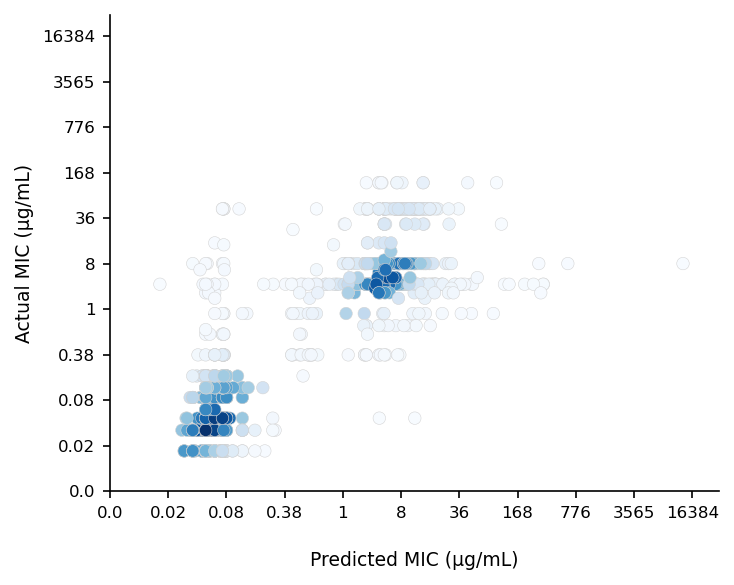

In [32]:
plot_ridge_results(os.path.join(results_path, "RIF_rpoBC"), saveName="Rifampicin/ridge_predictions.png")
# plot_ridge_results(os.path.join(results_path, "RIF_rpoBC_lineage"))

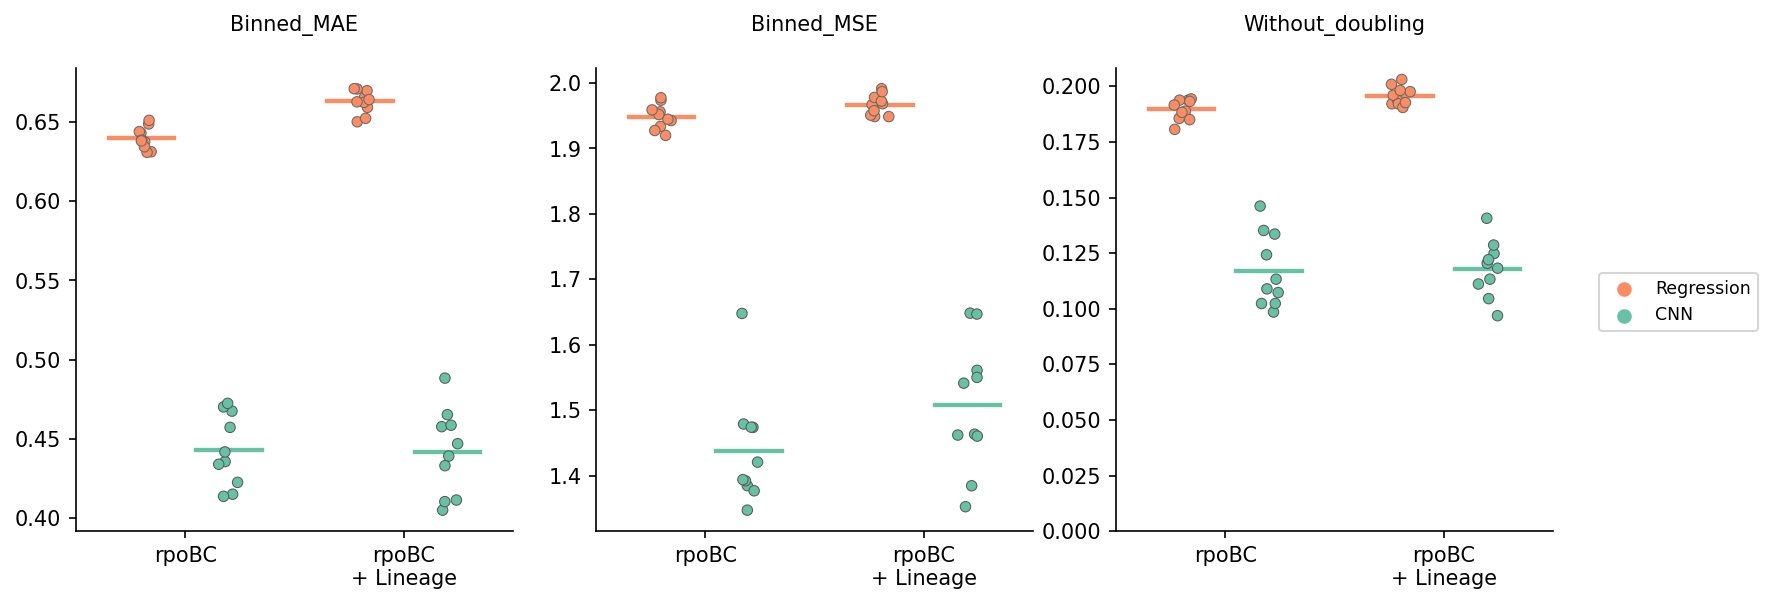

In [9]:
variable_lst = ["Binned_MAE", "Binned_MSE", "Without_doubling"]

plot_model_results(df_RIF, variable_lst, ["rpoBC", "rpoBC\n+ Lineage"], sharey=False, meanLine_width=0.3, 
                   lower_bounds=[None, None, 0], upper_bounds=[None, None, None], 
                   savefName="Rifampicin/quantitative_metrics.png"
                  )

# Isoniazid

In [13]:
df_INH = get_single_model_results("Isoniazid", "INH", "INH_4Loci", include_lineage=True, patience=25, cv=True, plot=False)

1941 points in validation set
Trained CNN for 60 epochs
1941 points in validation set
Trained CNN for 151 epochs


In [14]:
compare_two_models(df_INH.query("Model=='CNN' & Lineage==1"),
                   df_INH.query("Model=='CNN' & Lineage==0")
                  )

Binned_MAE, ns = 0.6231762238821174
Binned_MSE, ns = 0.47267559351158717
Spearman better, pval = 0.002293196040126747
Within_1Bin, ns = 0.6775849579524755
Within_doubling, ns = 0.12066463643502272
Sensitivity, ns = 0.3828784430737836
Specificity, ns = 0.1086194452259575
Balanced_Acc, ns = 0.17345557371239162


In [15]:
compare_two_models(df_INH.query("Model=='CNN' & Lineage==0"),
                   df_INH.query("Model=='LinReg' & Lineage==0")
                  )

Binned_MAE better, pval = 9.133589555477501e-05
Binned_MSE better, pval = 0.015604506385870109
Spearman better, pval = 0.015604506385870109
Within_1Bin better, pval = 9.082557304573249e-05
Within_doubling better, pval = 9.031736040376755e-05
Sensitivity better, pval = 0.01525666218288751
Specificity, ns = 0.5619440752989311
Balanced_Acc better, pval = 0.012874040410554032


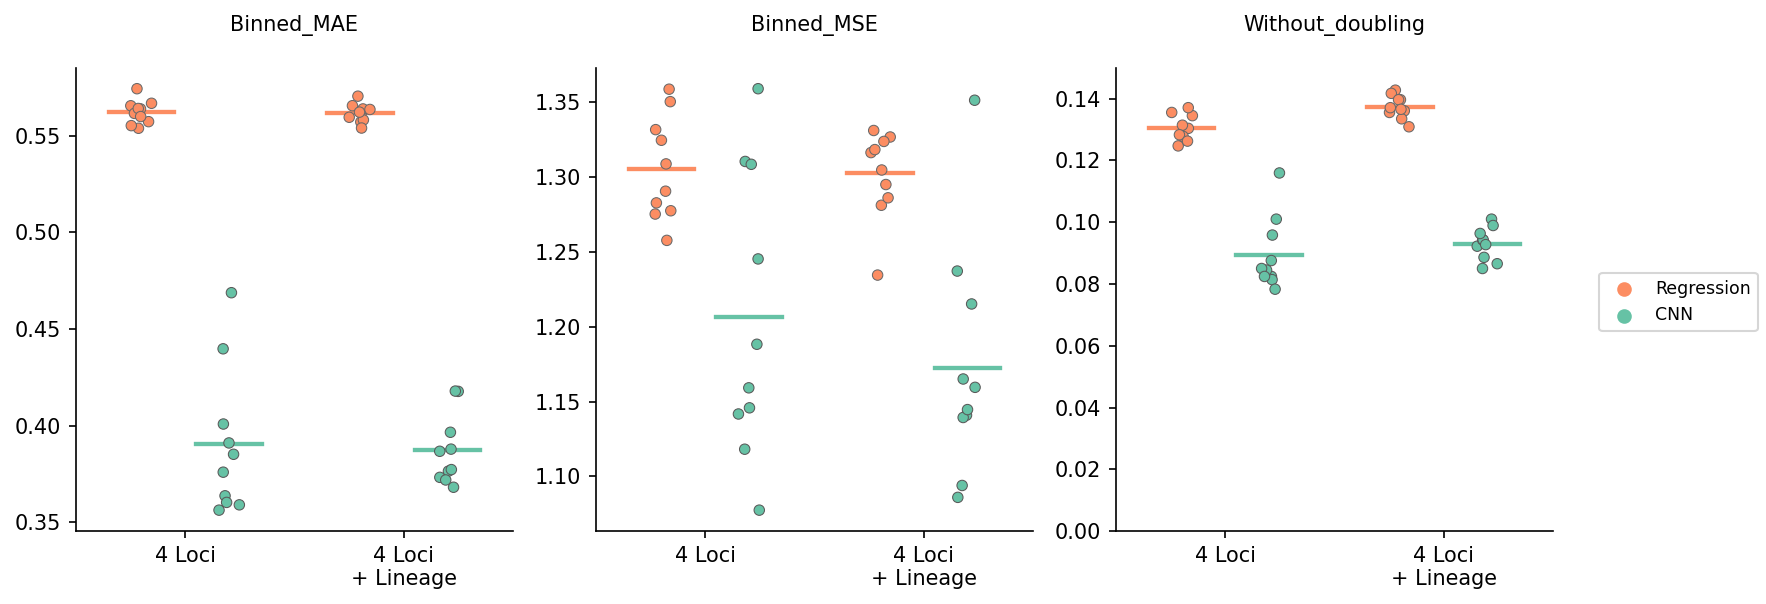

In [16]:
variable_lst = ["Binned_MAE", "Binned_MSE", "Without_doubling"]

plot_model_results(df_INH, variable_lst, ["4 Loci", "4 Loci\n+ Lineage"], sharey=False, meanLine_width=0.3, 
                   lower_bounds=[None, None, 0], upper_bounds=[None, None, 0.15], 
                   savefName="Isoniazid/quantitative_metrics.png"
                  )

# Ethambutol

In [10]:
df_EMB = get_single_model_results("Ethambutol", "EMB", "EMB_2Loci", include_lineage=True, patience=25, cv=True, plot=False)

1651 points in validation set
Trained CNN for 94 epochs
1651 points in validation set
Trained CNN for 99 epochs


In [10]:
compare_two_models(df_EMB.query("Model=='CNN' & Lineage==0"),
                   df_EMB.query("Model=='LinReg' & Lineage==0")
                  )

Binned_MAE, ns = 0.27303633975118835
Binned_MSE better, pval = 0.002293196040126747
Spearman worse, pval = 0.00029141997158965705
Within_1Bin worse, pval = 0.0006519583910106208
Within_doubling, ns = 0.47200855766610705
Sensitivity better, pval = 0.0010592836090070415
Specificity worse, pval = 0.0010926637394760297
Balanced_Acc better, pval = 0.0010968817870618656


In [9]:
compare_two_models(df_EMB.query("Model=='CNN' & Lineage==1"),
                   df_EMB.query("Model=='CNN' & Lineage==0")
                  )

Binned_MAE, ns = 0.06402210128302689
Binned_MSE better, pval = 0.015604506385870109
Spearman better, pval = 0.00012306406395261486
Within_1Bin, ns = 0.05868668127026371
Within_doubling better, pval = 0.002529385318464003
Sensitivity, ns = 0.3067609561706547
Specificity better, pval = 0.02237548140503554
Balanced_Acc, ns = 0.7337299956962472


In [12]:
compare_two_models(df_EMB.query("Model=='CNN' & Lineage==0"), df_EMB.query("Model=='LinReg' & Lineage==0"))

Binned_MAE, ns = 0.27303633975118835
Binned_MSE better, pval = 0.002293196040126747
Spearman worse, pval = 0.00029141997158965705
Within_1Bin worse, pval = 0.0006519583910106208
Within_doubling, ns = 0.47200855766610705
Sensitivity better, pval = 0.0010592836090070415
Specificity worse, pval = 0.0010926637394760297
Balanced_Acc better, pval = 0.0010968817870618656


In [13]:
compare_two_models(df_EMB.query("Model=='CNN' & Lineage==1"), df_EMB.query("Model=='LinReg' & Lineage==1"))

Binned_MAE better, pval = 0.0014136360455584039
Binned_MSE better, pval = 0.00021981937631328227
Spearman worse, pval = 0.004554248199015509
Within_1Bin worse, pval = 0.004528197122618649
Within_doubling, ns = 0.34086347595231237
Sensitivity better, pval = 0.0017926426839368992
Specificity worse, pval = 0.0022779269029296056
Balanced_Acc better, pval = 0.0014136360455584039


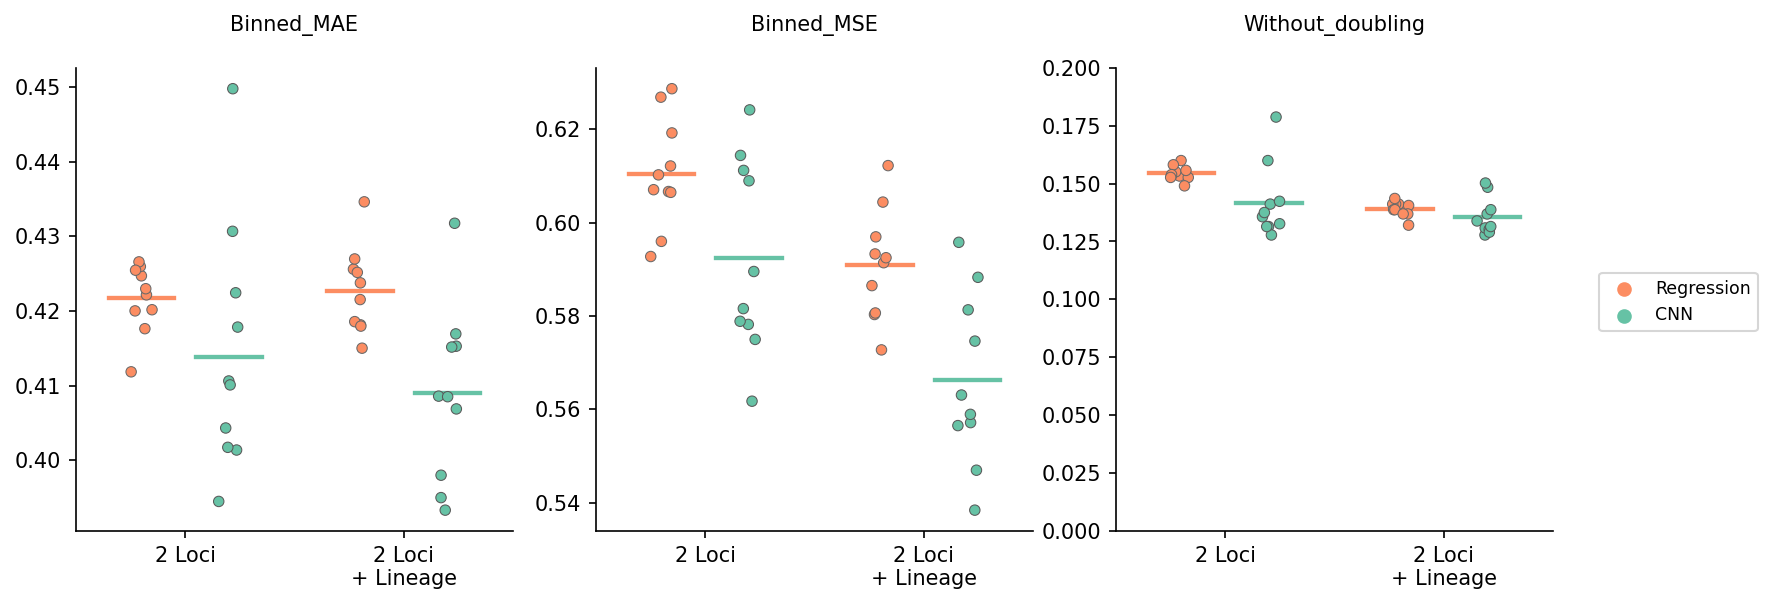

In [12]:
variable_lst = ["Binned_MAE", "Binned_MSE", "Without_doubling"]

plot_model_results(df_EMB, variable_lst, ["2 Loci", "2 Loci\n+ Lineage"], sharey=False, meanLine_width=0.3, 
                   lower_bounds=[None, None, 0], upper_bounds=[None, None, 0.2], 
                   savefName="Ethambutol/quantitative_metrics.png"
                  )

# Levofloxacin

In [6]:
drug = "LEV"
cc = 1
df_LEV_phenos = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/data_for_model.csv")

0.5629828243901169


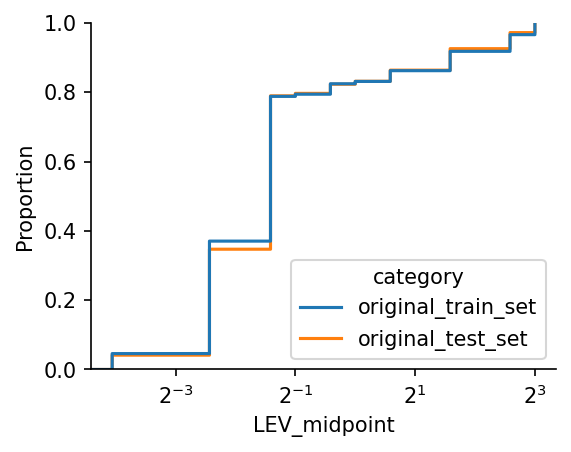

In [12]:
print(st.kstest(np.log2(df_LEV_phenos.query("category=='original_train_set'")[f"{drug}_midpoint"]), np.log2(df_LEV_phenos.query("category=='original_test_set'")[f"{drug}_midpoint"]), alternative="two-sided")[1])

fig, ax = plt.subplots(figsize=(4, 3))
sns.ecdfplot(data=df_LEV_phenos,
             x=f"{drug}_midpoint",
             log_scale=2,
             hue="category",
             ax=ax
            )
sns.despine()
plt.show()

In [24]:
df_LEV = get_single_model_results("Levofloxacin", "LEV", "LEV_gyrBA", include_lineage=True, patience=25, cv=True, plot=False)

1403 points in validation set
Trained CNN for 120 epochs
1403 points in validation set
Trained CNN for 66 epochs


In [25]:
compare_two_models(df_LEV.query("Model=='CNN' & Lineage==1"), df_LEV.query("Model=='CNN' & Lineage==0"))

Binned_MAE worse, pval = 0.0008531246844597495
Binned_MSE, ns = 0.21229383619233155
Spearman better, pval = 9.133589555477501e-05
Within_1Bin, ns = 0.3065784952080737
Within_doubling better, pval = 0.008357909104484756
Sensitivity worse, pval = 0.008661282739966025
Specificity, ns = 1.0
Balanced_Acc worse, pval = 0.008661282739966025


In [26]:
compare_two_models(df_LEV.query("Model=='CNN' & Lineage==0"), df_LEV.query("Model=='LinReg' & Lineage==0"))

Binned_MAE better, pval = 9.133589555477501e-05
Binned_MSE better, pval = 9.133589555477501e-05
Spearman worse, pval = 0.007009638556980002
Within_1Bin better, pval = 8.731210427609635e-05
Within_doubling better, pval = 8.880533034448187e-05
Sensitivity better, pval = 0.006660414206800123
Specificity, ns = 1.0
Balanced_Acc better, pval = 0.006660414206800123


In [27]:
compare_two_models(df_LEV.query("Model=='CNN' & Lineage==1"), df_LEV.query("Model=='LinReg' & Lineage==1"))

Binned_MAE better, pval = 9.133589555477501e-05
Binned_MSE better, pval = 9.133589555477501e-05
Spearman, ns = 0.5707503880581739
Within_1Bin, ns = 0.12970159207110524
Within_doubling, ns = 0.16118277069760312
Sensitivity better, pval = 0.0038174952445043644
Specificity, ns = 0.36812025069351895
Balanced_Acc better, pval = 0.003829428783225376


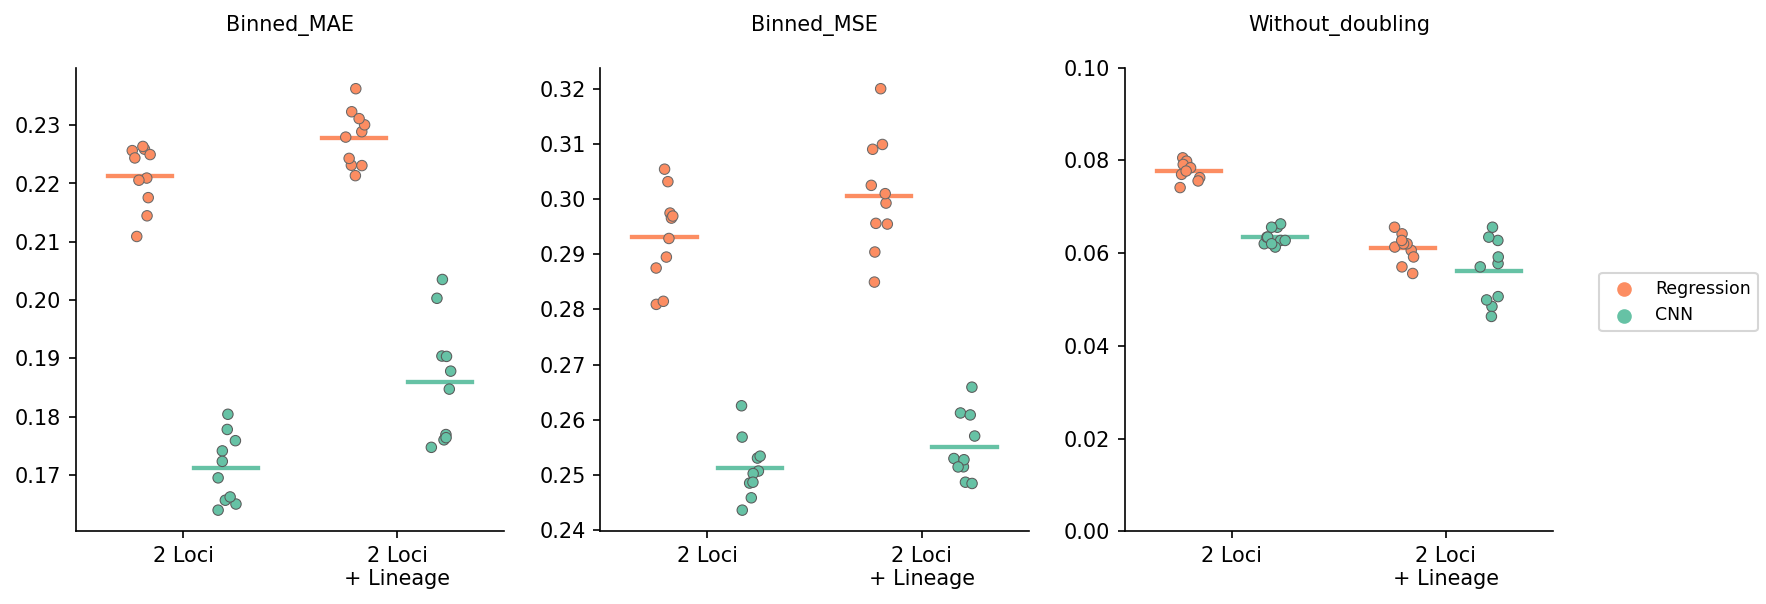

In [18]:
variable_lst = ["Binned_MAE", "Binned_MSE", "Without_doubling"]

plot_model_results(df_LEV, variable_lst, ["2 Loci", "2 Loci\n+ Lineage"], sharey=False, meanLine_width=0.3, 
                   lower_bounds=[None, None, 0], upper_bounds=[None, None, 0.1], 
                   savefName="Levofloxacin/quantitative_metrics.png"
                  )

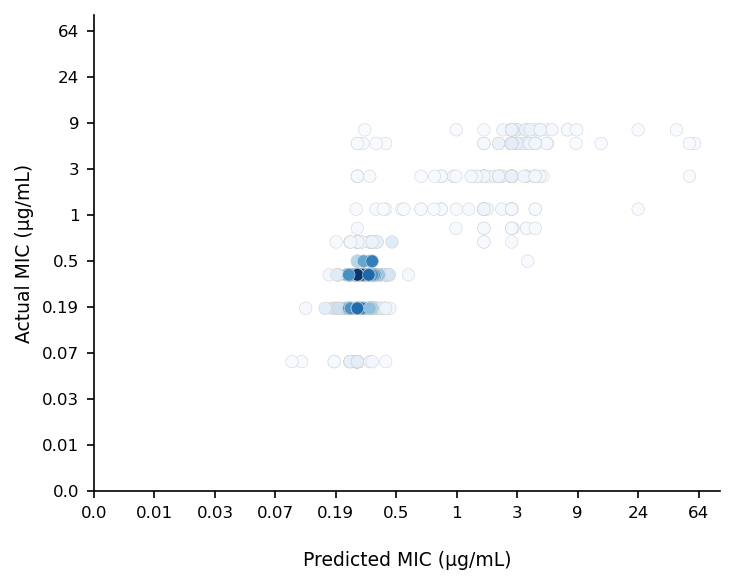

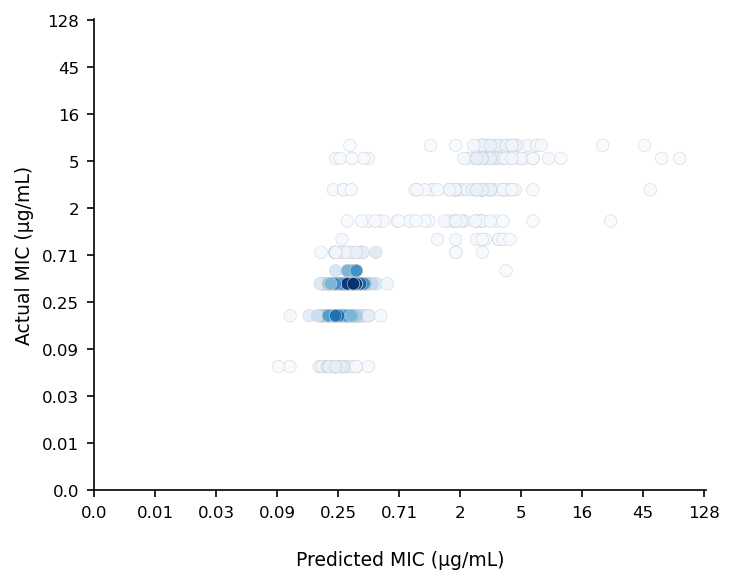

In [19]:
plot_ridge_results(os.path.join(results_path, "LEV_gyrBA"))
plot_ridge_results(os.path.join(results_path, "LEV_gyrBA_lineage"))

# Moxifloxacin

In [9]:
df_MXF = get_single_model_results("Moxifloxacin", "MXF", "MXF_gyrBA", include_lineage=True, patience=25, cv=True, plot=False)

1454 points in validation set
Trained CNN for 59 epochs
1454 points in validation set
Trained CNN for 80 epochs


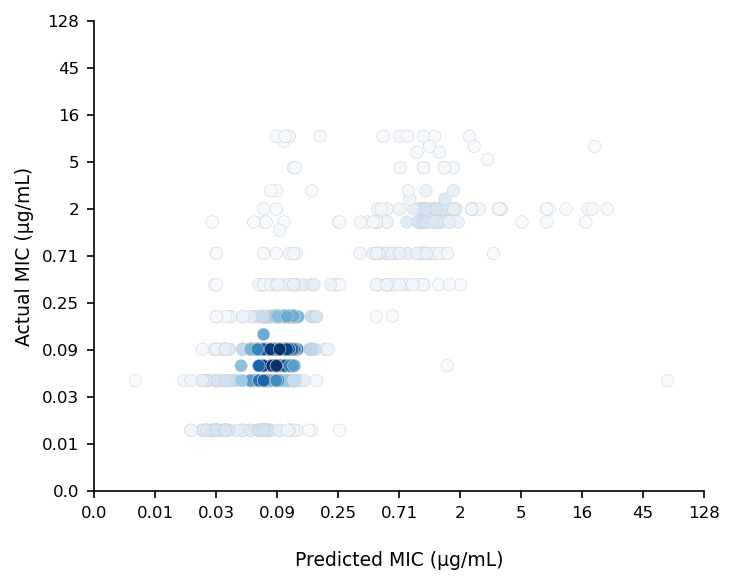

In [31]:
# plot_ridge_results(os.path.join(results_path, f"{path_mxf}"))
plot_ridge_results(os.path.join(results_path, "MXF_gyrBA_lineage"), saveName="Moxifloxacin/Reg_lineage_predictions.png")

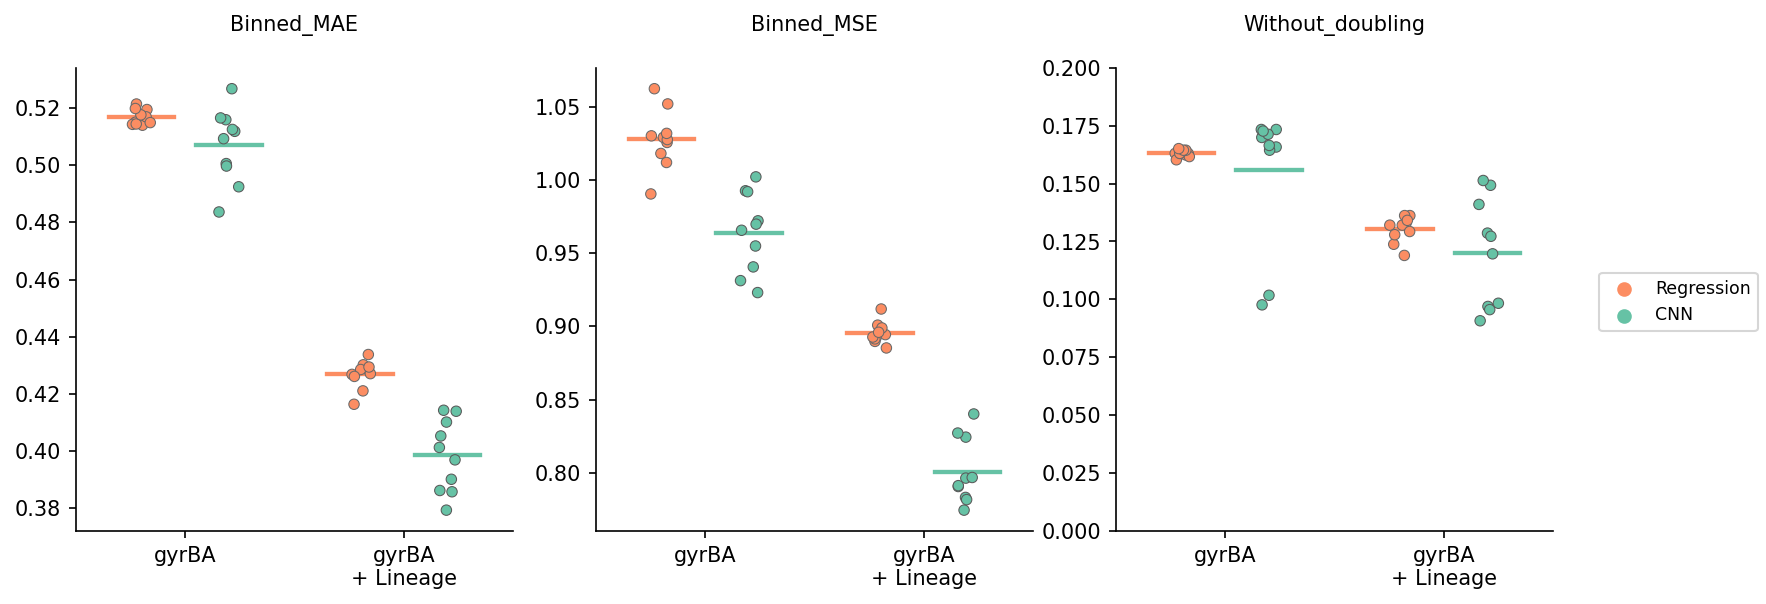

In [40]:
variable_lst = ["Binned_MAE", "Binned_MSE", "Without_doubling"]

plot_model_results(df_MXF, variable_lst, ["gyrBA", "gyrBA\n+ Lineage"], 
                   sharey=False, meanLine_width=0.3, lower_bounds=[None, None, 0], upper_bounds=[None, None, 0.2], 
                   savefName="Moxifloxacin/quantitative_metrics.png"
                  )

# Isoniazid

In [25]:
df_INH = get_single_model_results("Isoniazid", "INH", "INH_4Loci", include_lineage=True, patience=25, cv=True, plot=False)

1941 points in validation set
Trained CNN for 60 epochs
1941 points in validation set
Trained CNN for 151 epochs


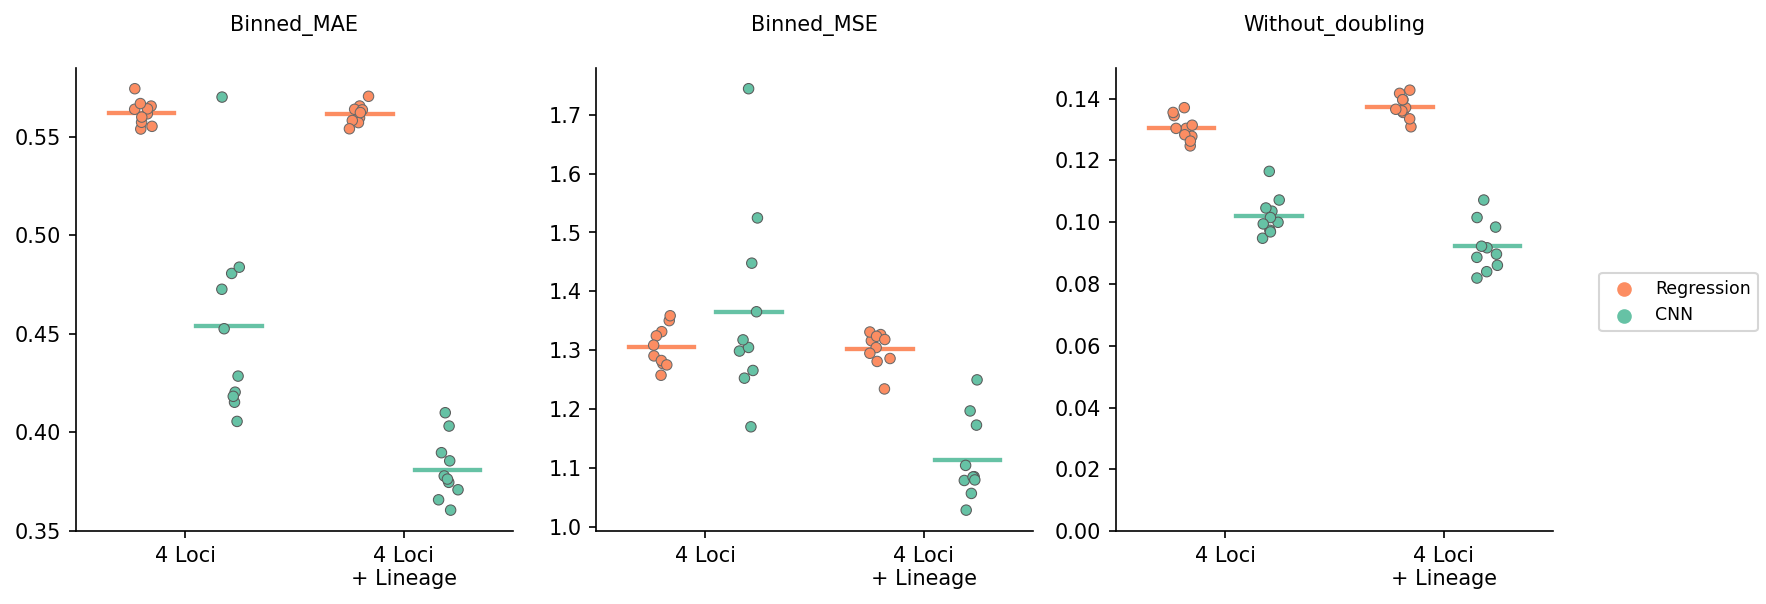

In [14]:
variable_lst = ["Binned_MAE", "Binned_MSE", "Without_doubling"]

plot_model_results(df_INH, variable_lst, ["4 Loci", "4 Loci\n+ Lineage"], 
                   sharey=False, meanLine_width=0.3, lower_bounds=[None, None, 0], upper_bounds=[None, None, 0.15], 
                   savefName="Isoniazid/quantitative_metrics.png"
                  )

In [15]:
compare_two_models(df_INH.query("Model=='CNN' & Lineage==1"), df_INH.query("Model=='CNN' & Lineage==0"))

Binned_MAE better, pval = 0.00012306406395261486
Binned_MSE better, pval = 0.00021981937631328227
Spearman better, pval = 9.133589555477501e-05
Within_1Bin better, pval = 0.0045281971226186785
Within_doubling better, pval = 0.006973639777895249
Sensitivity better, pval = 8.709635475283794e-05
Specificity worse, pval = 0.008626284249031002
Balanced_Acc better, pval = 0.004541213333820386


# Pyrazinamide

In [7]:
df_PZA = get_single_model_results("Pyrazinamide", "PZA", "PZA_4Loci", include_lineage=True, patience=0, cv=True, plot=False)
df_PZA_5Loci = get_single_model_results("Pyrazinamide", "PZA", "PZA_5Loci", include_lineage=True, patience=0, cv=True, plot=False)

241 points in validation set
Trained CNN for 250 epochs
241 points in validation set
Trained CNN for 250 epochs
241 points in validation set
Trained CNN for 250 epochs
241 points in validation set
Trained CNN for 250 epochs


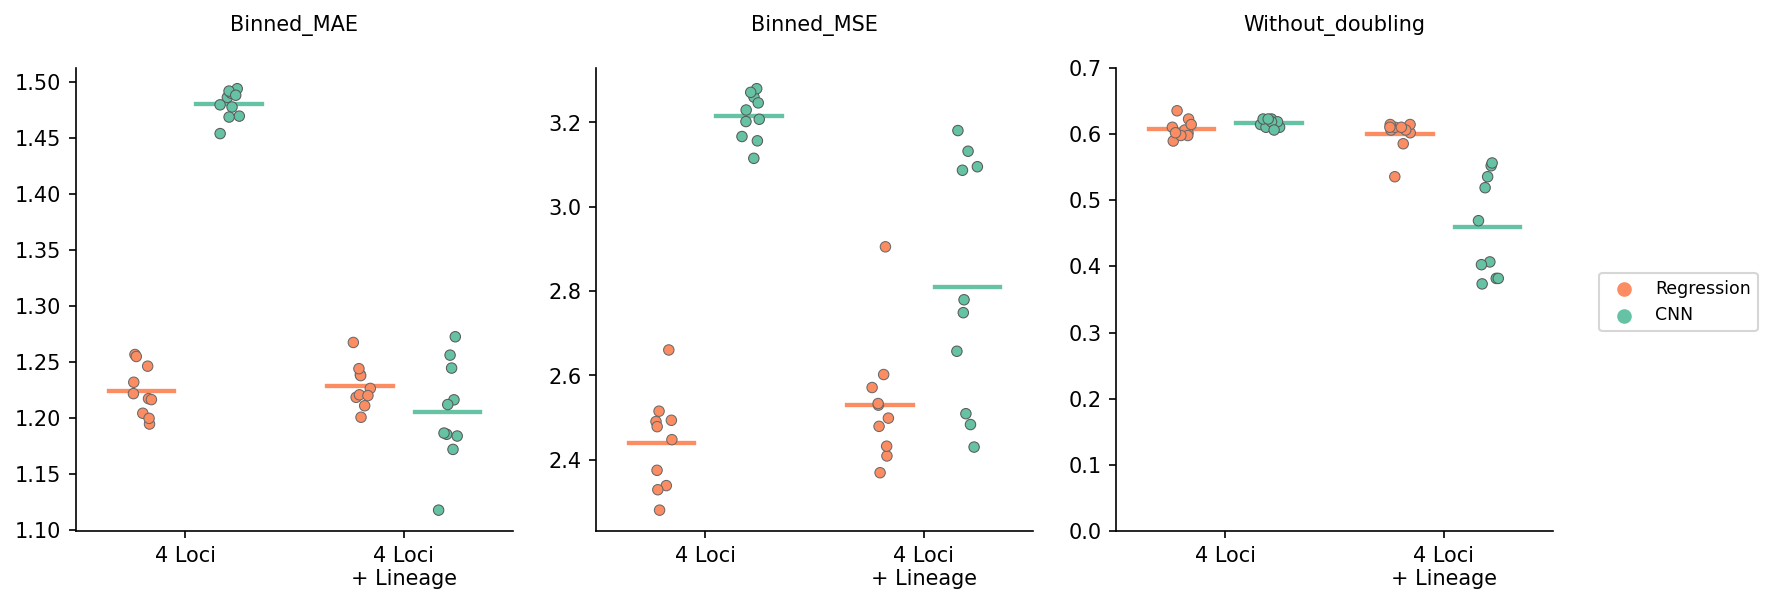

In [11]:
variable_lst = ["Binned_MAE", "Binned_MSE", "Without_doubling"]

plot_model_results(df_PZA, variable_lst, ["4 Loci", "4 Loci\n+ Lineage"], 
                   sharey=False, meanLine_width=0.3, lower_bounds=[None, None, 0], upper_bounds=[None, None, 0.7], 
                   #savefName="Pyrazinamide/quantitative_metrics.png"
                  )

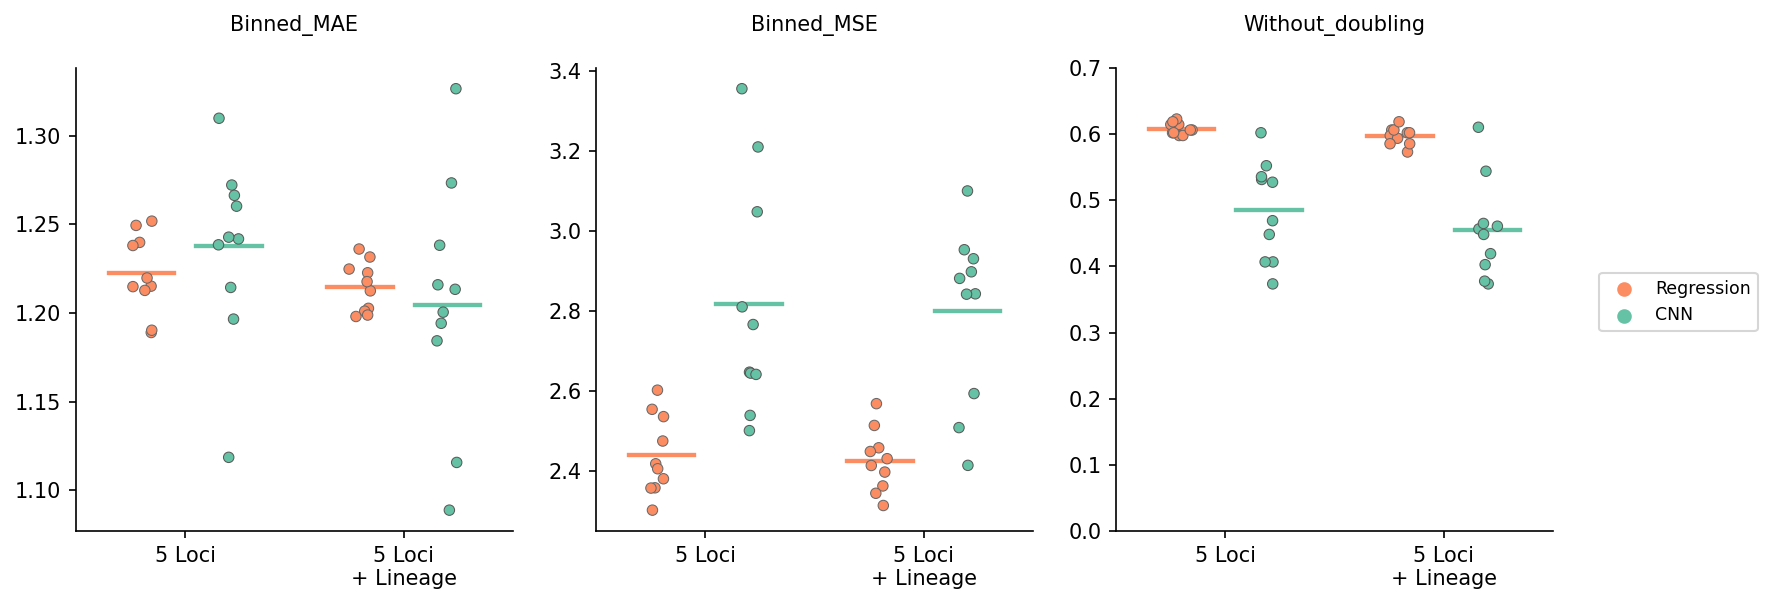

In [12]:
variable_lst = ["Binned_MAE", "Binned_MSE", "Without_doubling"]

plot_model_results(df_PZA_5Loci, variable_lst, ["5 Loci", "5 Loci\n+ Lineage"], 
                   sharey=False, meanLine_width=0.3, lower_bounds=[None, None, 0], upper_bounds=[None, None, 0.7], 
                   #savefName="Pyrazinamide/quantitative_metrics.png"
                  )

In [29]:
history = pd.read_csv(os.path.join(results_path, "PZA_5Loci_lineage/history.csv"))

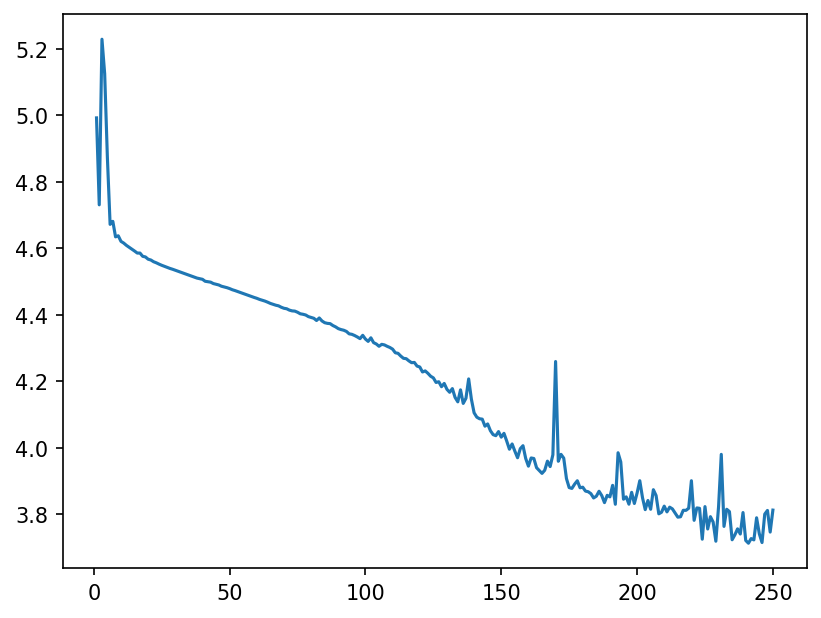

In [ ]:
plt.plot(history.index.values+1, history.val_loss.values)

In [21]:
df_PZA_5Loci = get_single_model_results("Pyrazinamide", "PZA", "PZA_5Loci", include_lineage=True, patience=0, cv=True, plot=False)

241 points in validation set
Trained CNN for 250 epochs
241 points in validation set
Trained CNN for 250 epochs


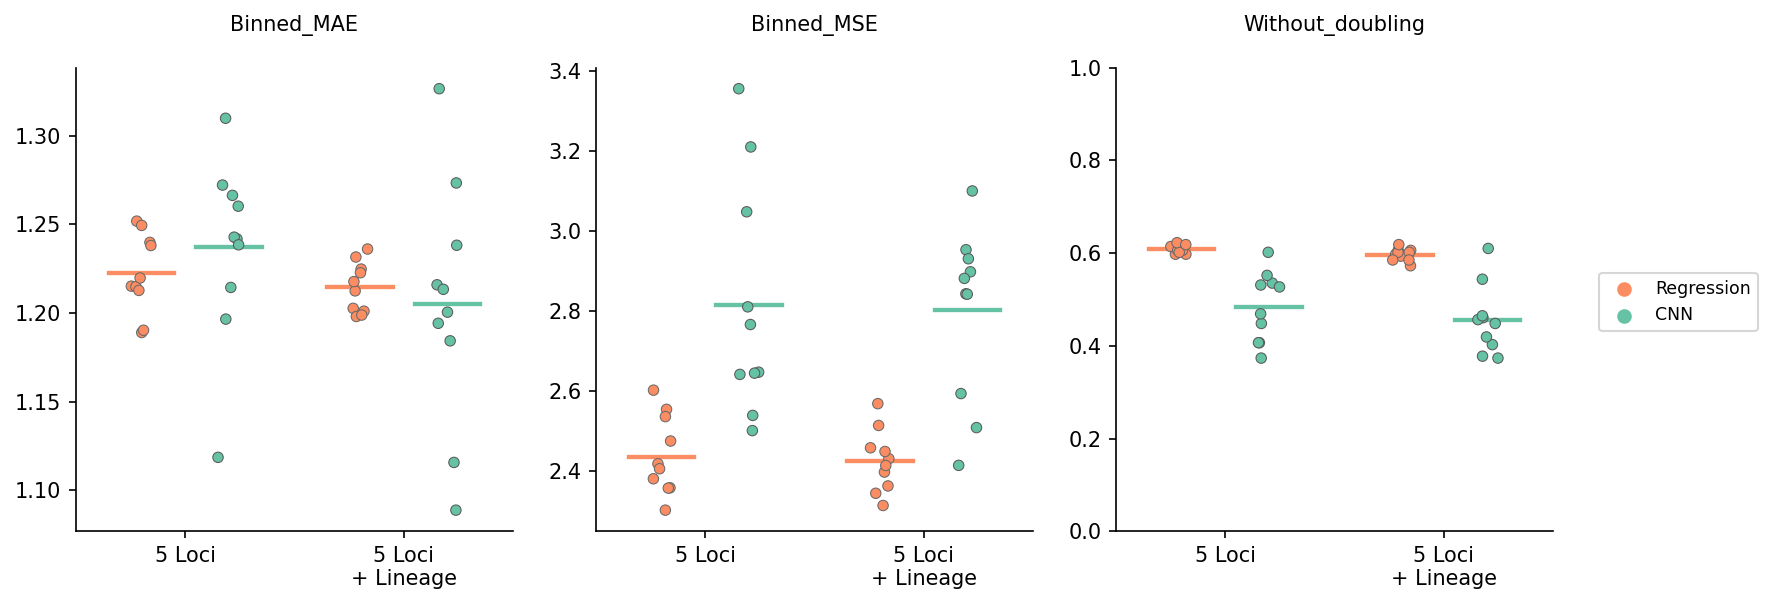

In [13]:
variable_lst = ["Binned_MAE", "Binned_MSE", "Without_doubling"]

plot_model_results(df_PZA_5Loci, variable_lst, ["5 Loci", "5 Loci\n+ Lineage"], 
                   sharey=False, meanLine_width=0.3, lower_bounds=[None, None, 0], upper_bounds=[None, None, 1], 
                   #savefName="Pyrazinamide/quantitative_metrics.png"
                  )

In [139]:
def plot_residuals(path, pred_col="y_pred", actual_col="y_test"):
    
    pred_df = pd.read_csv(os.path.join(path, "test_predictions.csv"))
    pred_df["residual"] = pred_df[actual_col] - pred_df[pred_col]
    
    sns.residplot(data=pred_df, x=actual_col, y="residual")
    plt.xlabel("Test Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    sns.despine()
    plt.show()

In [89]:
# plot_residuals(os.path.join(results_path, path_rif, "ridge"))

In [90]:
# plot_residuals(os.path.join(results_path, path_rif))

In [91]:
# plot_residuals(os.path.join(results_path, path_mxf))

In [68]:
drug = "MXF"
lower_col = f"{drug}_lower_bound"
upper_col = f"{drug}_upper_bound"
df_phenos = df_mxf.copy()

summary_table = pd.DataFrame(df_phenos.groupby([lower_col, upper_col])["ROLLINGDB_ID"].count())#.sort_values(ascending=False))
summary_table = summary_table.rename(columns={"ROLLINGDB_ID": "Count"}).reset_index()
summary_table = summary_table.sort_values([lower_col, upper_col], ascending=[True, True])

In [71]:
for i, row in summary_table.iterrows():

    lower, upper = row[lower_col], row[upper_col]
    unique_db = ", ".join(df_phenos.query(f"{lower_col}==@lower & {upper_col}==@upper").DB_OF_ORIGIN.unique())
    summary_table.loc[i, "Databases"] = unique_db

In [73]:
summary_table.to_csv(f"../{drug}_summary_table.csv", index=False)

In [140]:
compare_two_models(rif_CNN, rif_Reg)

Binned_MAE better, pval = 9.133589555477501e-05
Binned_MSE better, pval = 9.133589555477501e-05
Spearman better, pval = 0.0008531246844597982
Within_1Bin better, pval = 8.930724418684081e-05
Within_doubling better, pval = 9.031736040376755e-05
Sensitivity better, pval = 0.0005855783543037018
Specificity worse, pval = 0.0002653958272035295
Balanced_Acc better, pval = 0.0013724929818506651


In [141]:
# lineage doesn't significantly affect CNN
compare_two_models(rif_lineage_CNN, rif_CNN)

Binned_MAE, ns = 0.7337299956962472
Binned_MSE, ns = 0.21229383619233155
Spearman, ns = 0.3447042220069576
Within_1Bin, ns = 0.4270075030844239
Within_doubling, ns = 0.7621953377876631
Sensitivity, ns = 0.5981677847737634
Specificity, ns = 0.7263386976487618
Balanced_Acc, ns = 0.2564924378606587


In [142]:
# lineage doesn't significantly affect regression
compare_two_models(rif_lineage_Reg, rif_Reg)

Binned_MAE worse, pval = 0.00566484834223735
Binned_MSE, ns = 0.10410988966022681
Spearman, ns = 0.12122450301291662
Within_1Bin, ns = 0.06911774809372985
Within_doubling, ns = 0.09592822394950809
Sensitivity, ns = 0.4256100315999112
Specificity, ns = 0.22172532768851927
Balanced_Acc, ns = 0.969838641404833


## Isolates with reference H37Rv sequence but are predicted resistant

In [124]:
compare_two_models(mxf_lineage_CNN, mxf_CNN)

Binned_MAE better, pval = 9.133589555477501e-05
Binned_MSE better, pval = 9.133589555477501e-05
Spearman better, pval = 9.133589555477501e-05
Within_1Bin, ns = 0.10358920441921747
Within_doubling better, pval = 0.0028884892918371497
Sensitivity, ns = 0.6703728741924714
Specificity better, pval = 8.985049752419998e-05
Balanced_Acc, ns = 0.2407903676416846


In [125]:
compare_two_models(mxf_lineage_Reg, mxf_Reg)

Binned_MAE better, pval = 9.133589555477501e-05
Binned_MSE better, pval = 9.133589555477501e-05
Spearman better, pval = 9.133589555477501e-05
Within_1Bin better, pval = 0.00625567469163966
Within_doubling better, pval = 8.486480433072498e-05
Sensitivity worse, pval = 0.0002684161644450622
Specificity better, pval = 8.012318266794122e-05
Balanced_Acc worse, pval = 0.0003825114754596459


In [126]:
compare_two_models(mxf_lineage_CNN, mxf_lineage_Reg)

Binned_MAE better, pval = 9.133589555477501e-05
Binned_MSE better, pval = 9.133589555477501e-05
Spearman, ns = 0.5707503880581739
Within_1Bin, ns = 0.3255694067409992
Within_doubling, ns = 0.3071254747827329
Sensitivity better, pval = 0.00029581223237671364
Specificity, ns = 0.08392571583056095
Balanced_Acc better, pval = 0.00021872746058138314


In [150]:
def compute_normalized_MAE(df_phenos, drug, CNN_df, Reg_df):

    dist_std = np.log2(df_phenos[f"{drug}_midpoint"]).std()
    error_diff = Reg_df.query("CV==0")["Binned_MAE"].values[0] - CNN_df.query("CV==0")["Binned_MAE"].values[0]

    norm_mean = error_diff / dist_std

    bootstrap_norm_means = []

    for i in range(len(CNN_df)-1):
        bootstrap_error_diff = Reg_df.query(f"CV=={i+1}")["Binned_MAE"].values[0] - CNN_df.query(f"CV=={i+1}")["Binned_MAE"].values[0]
        bootstrap_norm_means.append(bootstrap_error_diff / dist_std)

    print(norm_mean, np.percentile(bootstrap_norm_means, q=[2.5, 97.5]))

In [153]:
compute_normalized_MAE(df_rif, "RIF", rif_CNN, rif_Reg)

0.06391520037386678 [0.04916727 0.06935892]


In [151]:
compute_normalized_MAE(df_mxf, "MXF", mxf_lineage_CNN, mxf_lineage_Reg)

0.018830835198428444 [0.00407592 0.02317101]


In [69]:
dist_std = np.log2(df_mxf["MXF_midpoint"]).std()
dist_std

2.0166051474723705

In [70]:
error_diff = mxf_lineage_Reg.query("CV==0")["Binned_MAE"].values[0] - mxf_lineage_CNN.query("CV==0")["Binned_MAE"].values[0]
error_diff

0.0379743591923547

In [71]:
error_diff / dist_std

0.018830835198428444

In [72]:
dist_std = np.log2(df_rif["RIF_midpoint"]).std()
dist_std

3.8114028665763824

In [73]:
error_diff = rif_Reg.query("CV==0")["Binned_MAE"].values[0] - rif_CNN.query("CV==0")["Binned_MAE"].values[0]
error_diff

0.2436065779227597

In [74]:
error_diff / dist_std

0.06391520037386678

In [28]:
np.log2(df_mxf["MXF_midpoint"]).max(), np.log2(df_mxf["MXF_midpoint"]).min()

(3.321928094887362, -6.058893689053568)

# Distribution of Mispredictions

In [27]:
def error_dist(cnn_dir):
    
    path = os.path.join(results_path, cnn_dir)
    pred = pd.read_csv(os.path.join(path, "test_predictions.csv"))
    
    fig, ax = plt.subplots()
    sns.histplot(pred.y_pred - pred.y_test, stat="probability", ax=ax)
    plt.axvline(np.mean(pred.y_pred - pred.y_test), color="black", linestyle="-")
    
    print(f"Average Error: {np.round(np.mean(pred.y_pred - pred.y_test), 2)}")
    #ax.set_xticks(ticks=ax.get_xticks(), labels=np.round(np.exp2(ax.get_xticks()), 2))
    
    plt.title("Predicted log-MIC - Actual log-MIC")
    sns.despine()
    plt.show()

In [29]:
# error_dist("RIF_rpoBC")

In [56]:
# error_dist("RIF_rpoBC_lineage")

In [25]:
df_pred_CNN = pd.read_csv(os.path.join(results_path, "RIF_rpoBC/test_predictions.csv"))
df_pred_Reg = pd.read_csv(os.path.join(results_path, "RIF_rpoBC/ridge/test_predictions.csv"))

In [42]:
RIF_test_variants = RIF_isolate_variants.query("Isolate in @df_pred_CNN.Isolate.values")
RIF_test_variants["mutation"] = RIF_test_variants["GENE"] + "_" + RIF_test_variants["PROT"]

cat1_mutations = who_variants_clean.query("drug == 'RIF' & confidence=='1) Assoc w R'").mutation.values
isolates_R = RIF_test_variants.query("mutation in @cat1_mutations & FILTER == 'PASS'").Isolate.values

In [64]:
df_pred_catalog = df_pred_CNN[["Isolate", "y_test_exp"]]
df_pred_catalog["y_test"] = (df_pred_CNN["y_test_exp"] > 0.5).astype(int)
df_pred_catalog["y_pred"] = df_pred_catalog["Isolate"].map(dict(zip(isolates_R, np.ones(len(isolates_R)))))
df_pred_catalog["y_pred"] = df_pred_catalog["y_pred"].fillna(0).astype(int)

In [65]:
df_pred_catalog

,Isolate,y_test_exp,y_test,y_pred
0,ERR4810495,0.090,0,0
1,ERR4810512,0.030,0,0
2,ERR4810526,0.030,0,0
3,ERR4810535,0.030,0,0
4,ERR4810584,0.030,0,0
...,...,...,...,...
1822,SAMN02380986,0.185,0,0
1823,SAMN02364077,16.000,1,1
1824,SAMEA3558171,120.000,1,1
1825,SAMEA3558209,120.000,1,1


In [66]:
df_pred_catalog.query("y_test != y_pred")

,Isolate,y_test_exp,y_test,y_pred
11,ERR4810867,4.000,1,0
15,ERR4810933,4.000,1,0
18,ERR4810962,4.000,1,0
80,ERR4810726,3.000,1,0
107,ERR4810780,0.750,1,0
...,...,...,...,...
1754,Peru5141,50.000,1,0
1763,Peru5447,50.000,1,0
1766,TDR105S128L002,0.875,1,0
1809,SAMN02360567,16.000,1,0


In [83]:
pd.concat([rif_CNN, rif_Reg], axis=0).drop_duplicates(["Model", "CV"], keep="first").shape

(22, 18)

In [84]:
pd.concat([rif_CNN, rif_Reg], axis=0).to_csv("Rifampicin/CNN_Reg_results.csv", index=False)